# Practical Application III: Comparing Classifiers

**Overview**: In this practical application, your goal is to compare the performance of the classifiers we encountered in this section, namely K Nearest Neighbor, Logistic Regression, Decision Trees, and Support Vector Machines.  We will utilize a dataset related to marketing bank products over the telephone.  



### Getting Started

Our dataset comes from the UCI Machine Learning repository [link](https://archive.ics.uci.edu/ml/datasets/bank+marketing).  The data is from a Portugese banking institution and is a collection of the default_res of multiple marketing campaigns.  We will make use of the article accompanying the dataset [here](CRISP-DM-BANK.pdf) for more information on the data and features.



### Problem 1: Understanding the Data

To gain a better understanding of the data, please read the information provided in the UCI link above, and examine the **Materials and Methods** section of the paper.  How many marketing campaigns does this data represent?

<font color="MidnightBlue">The data represents 17 marketing campaigns <font>

### Problem 2: Read in the Data

Use pandas to read in the dataset `bank-additional-full.csv` and assign to a meaningful variable name.

In [369]:
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn import svm
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score
from matplotlib import pyplot as plt
from sklearn.model_selection import GridSearchCV
import time
from sklearn.metrics import f1_score
import seaborn as sns

In [370]:
df = pd.read_csv('data/bank-additional-full.csv', sep = ';')

In [371]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


### Problem 3: Understanding the Features


Examine the data description below, and determine if any of the features are missing values or need to be coerced to a different data type.


```
Input variables:
# bank client data:
1 - age (numeric)
2 - job : type of job (categorical: 'admin.','blue-collar','entrepreneur','housemaid','management','retired','self-employed','services','student','technician','unemployed','unknown')
3 - marital : marital status (categorical: 'divorced','married','single','unknown'; note: 'divorced' means divorced or widowed)
4 - education (categorical: 'basic.4y','basic.6y','basic.9y','high.school','illiterate','professional.course','university.degree','unknown')
5 - default: has credit in default? (categorical: 'no','yes','unknown')
6 - housing: has housing loan? (categorical: 'no','yes','unknown')
7 - loan: has personal loan? (categorical: 'no','yes','unknown')
# related with the last contact of the current campaign:
8 - contact: contact communication type (categorical: 'cellular','telephone')
9 - month: last contact month of year (categorical: 'jan', 'feb', 'mar', ..., 'nov', 'dec')
10 - day_of_week: last contact day of the week (categorical: 'mon','tue','wed','thu','fri')
11 - duration: last contact duration, in seconds (numeric). Important note: this attribute highly affects the output target (e.g., if duration=0 then y='no'). Yet, the duration is not known before a call is performed. Also, after the end of the call y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model.
# other attributes:
12 - campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)
13 - pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric; 999 means client was not previously contacted)
14 - previous: number of contacts performed before this campaign and for this client (numeric)
15 - poutcome: outcome of the previous marketing campaign (categorical: 'failure','nonexistent','success')
# social and economic context attributes
16 - emp.var.rate: employment variation rate - quarterly indicator (numeric)
17 - cons.price.idx: consumer price index - monthly indicator (numeric)
18 - cons.conf.idx: consumer confidence index - monthly indicator (numeric)
19 - euribor3m: euribor 3 month rate - daily indicator (numeric)
20 - nr.employed: number of employees - quarterly indicator (numeric)

Output variable (desired target):
21 - y - has the client subscribed a term deposit? (binary: 'yes','no')
```



In [372]:
df.isnull().sum()

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

### Problem 4: Understanding the Task

After examining the description and data, your goal now is to clearly state the *Business Objective* of the task.  State the objective below.

In [373]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  str    
 2   marital         41188 non-null  str    
 3   education       41188 non-null  str    
 4   default         41188 non-null  str    
 5   housing         41188 non-null  str    
 6   loan            41188 non-null  str    
 7   contact         41188 non-null  str    
 8   month           41188 non-null  str    
 9   day_of_week     41188 non-null  str    
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  str    
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null  float64
 1

<font color="MidnightBlue">The business objective is to identify which bank customers are most likely to subscribe to a term deposit, allowing the bank to target its marketing campaigns more effectively and reduce the resources spent on unsuccessful contacts.</font>

### Problem 5: Engineering Features

Now that you understand your business objective, we will build a basic model to get started.  Before we can do this, we must work to encode the data.  Using just the bank information features, prepare the features and target column for modeling with appropriate encoding and transformations.

<font color="MidnightBlue">We need to convert str to numeric data using ohe and scale the data
</font>

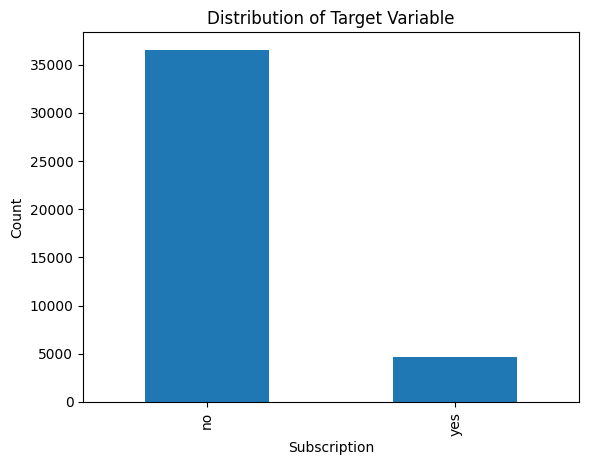

In [374]:
df['y'].value_counts().plot(kind='bar')

plt.xlabel('Subscription')
plt.ylabel('Count')
plt.title('Distribution of Target Variable')
plt.show()

In [375]:
X = df.drop(columns = ['duration', 'y'])
y = df['y'].str.strip().map({"yes": 1, "no": 0})
catColumns = X.select_dtypes(['str']).columns
preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown = 'ignore'), catColumns)
], remainder = 'passthrough')

X = preprocessor.fit_transform(X)



### Problem 6: Train/Test Split

With your data prepared, split it into a train and test set.

In [376]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)


In [377]:
scaler = StandardScaler(with_mean=False)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


### Problem 7: A Baseline Model

Before we build our first model, we want to establish a baseline.  What is the baseline performance that our classifier should aim to beat?

In [378]:
baseline = DummyClassifier(strategy='stratified')
baseline.fit(X_train_scaled, y_train)
y_pred = baseline.predict(X_test_scaled)
print(f"Accuracy score: {accuracy_score(y_test, y_pred)}")
print(f"F1 score: {f1_score(y_test, y_pred)}")

Accuracy score: 0.8032289390628793
F1 score: 0.1049144119271121


<font color="MidnightBlue">I am using stratified as a strategy to be able to have a dummy F1 score. </font>

### Problem 8: A Simple Model

Use Logistic Regression to build a basic model on your data.

In [379]:
lr = LogisticRegression(max_iter=1000, solver='liblinear', random_state=42)

start = time.time()
lr.fit(X_train_scaled, y_train)
end = time.time()

### Problem 9: Score the Model

What is the accuracy of your model?

In [380]:
lr.score(X_test_scaled, y_test)

0.9017965525613013

### Problem 10: Model Comparisons

Now, we aim to compare the performance of the Logistic Regression model to our KNN algorithm, Decision Tree, and SVM models.  Using the default settings for each of the models, fit and score each.  Also, be sure to compare the fit time of each of the models.  Present your findings in a `DataFrame` similar to that below:

| Model | Train Time | Train Accuracy | Test Accuracy |
| ----- | ---------- | -------------  | -----------   |
|     |    |.     |.     |

In [381]:
default_res = {"Model": ["LR"], "Train Time": [end - start], "Train Accuracy": [lr.score(X_train_scaled, y_train)], "Test Accuracy": [lr.score(X_test_scaled, y_test)],}

In [382]:
knn = KNeighborsClassifier()
start = time.time()
knn.fit(X_train_scaled, y_train)
end = time.time()

default_res["Model"].append("KNN")
default_res["Train Time"].append(end - start)
default_res["Train Accuracy"].append(knn.score(X_train_scaled, y_train))
default_res["Test Accuracy"].append(knn.score(X_test_scaled, y_test))

In [383]:
dtree = DecisionTreeClassifier()

start = time.time()
dtree.fit(X_train, y_train)
end = time.time()
default_res["Model"].append("Decision Tree")
default_res["Train Time"].append(end - start)
default_res["Train Accuracy"].append(dtree.score(X_train, y_train))
default_res["Test Accuracy"].append(dtree.score(X_test, y_test))


In [384]:
svc = svm.SVC()

start = time.time()
svc.fit(X_train_scaled, y_train)
end = time.time()
default_res["Model"].append("SVM")
default_res["Train Time"].append(end - start)
default_res["Train Accuracy"].append(svc.score(X_train_scaled, y_train))
default_res["Test Accuracy"].append(svc.score(X_test_scaled, y_test))


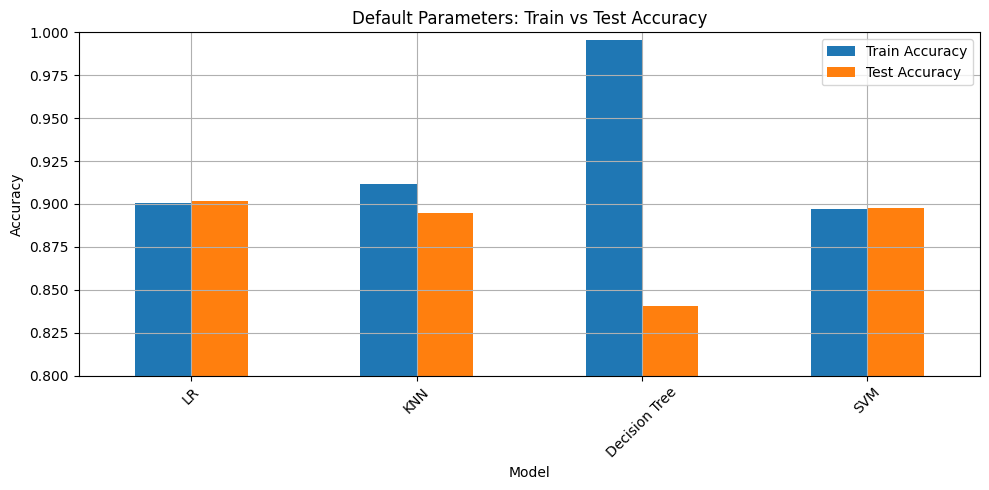

In [385]:
default_res = pd.DataFrame(default_res)

default_res.plot(
    x="Model",
    y=["Train Accuracy", "Test Accuracy"],
    kind="bar",
    figsize=(10, 5)
)

plt.ylabel("Accuracy")
plt.title("Default Parameters: Train vs Test Accuracy")
plt.ylim(0.8, 1.0)
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.grid(True)
plt.show()

<font color="MidnightBlue">From the plot above, we see that Decision tree with the default params has shown the highest train accuracy score, and the lowest test score which indicates that the model is overfitted. Knn seems to be slightly overfitted as well. LogReg and SVC showed similar accuracy scores between their train and test data sets. SVM has slightly lower accuracy score than LogReg. Out of all these models with default params, I would chose LogReg as it showed the best bias/variance balance.

Remidning the baseline results:
Accuracy score: 0.8018936635105608

So all our models have performed better than the random classification.
</font>

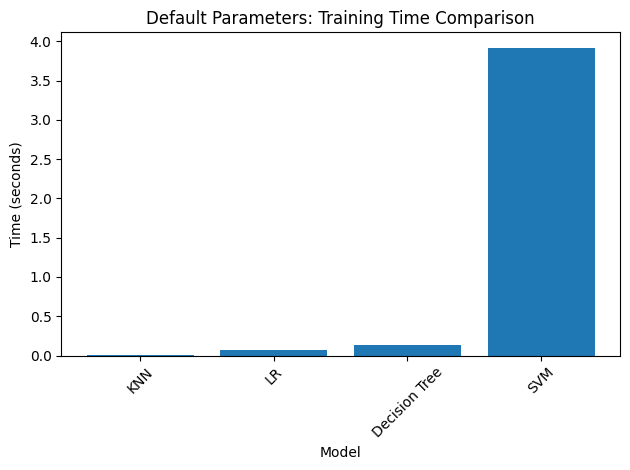

In [386]:
sorted_res = default_res.sort_values("Train Time")

plt.bar(sorted_res["Model"], sorted_res["Train Time"])

plt.xlabel("Model")
plt.ylabel("Time (seconds)")
plt.title("Default Parameters: Training Time Comparison")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [387]:
default_res

,Model,Train Time,Train Accuracy,Test Accuracy
0,LR,0.072361,0.900364,0.901797
1,KNN,0.001152,0.911472,0.894635
2,Decision Tree,0.131167,0.995417,0.840495
3,SVM,3.917177,0.897329,0.897791


<font color= "MidnightBlue">The longest training time belongs to SVM model, as expected, and the fastest to train turned out to be KNN. </font>

### Problem 11: Improving the Model

Now that we have some basic models on the board, we want to try to improve these.  Below, we list a few things to explore in this pursuit.


- Hyperparameter tuning and grid search.  All of our models have additional hyperparameters to tune and explore.  For example the number of neighbors in KNN or the maximum depth of a Decision Tree.  
- Adjust your performance metric

<font color="MidnightBlue">Because the target classes are imbalanced, accuracy alone can be misleading. I use F1 score as the primary evaluation metric because it balances precision and recall and therefore provides a better measure of the model's ability to identify customers who are likely to subscribe. <font>

In [388]:
tuned_res = {"Model": [], "Train Time": [], "Train F1": [], "Test F1": []}

In [389]:
y_train.value_counts()

y
0    29238
1     3712
Name: count, dtype: int64

In [390]:
print(y_train.value_counts(dropna=False))
print(y_test.value_counts(dropna=False))

y
0    29238
1     3712
Name: count, dtype: int64
y
0    7310
1     928
Name: count, dtype: int64


In [391]:
t_lr = LogisticRegression(max_iter=5000, solver='liblinear')

params = {'C': [0.01, 0.1, 1], 'l1_ratio': [0], 'class_weight': [None, 'balanced'],}
lr_grid = GridSearchCV(estimator=t_lr, param_grid=params, scoring='f1', cv = 3, n_jobs=-1)

lr_grid.fit(X_train_scaled, y_train)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...r='liblinear')
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.01, 0.1, ...], 'class_weight': [None, 'balanced'], 'l1_ratio': [0]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity

In [392]:
best_index = lr_grid.best_index_


In [393]:
train_pred = lr_grid.best_estimator_.predict(X_train_scaled)
test_pred = lr_grid.best_estimator_.predict(X_test_scaled)

tuned_res["Model"].append("Tuned LR")
tuned_res["Train Time"].append(lr_grid.cv_results_['mean_fit_time'][best_index])
tuned_res["Train F1"].append(f1_score(y_train, train_pred))
tuned_res["Test F1"].append(f1_score(y_test, test_pred))


In [394]:
t_knn = KNeighborsClassifier()
params = {'n_neighbors': [10, 20, 30, 40, 50, 60, 80], 'weights': ['uniform', 'distance'], 'metric':['euclidean', 'manhattan']}
grid = GridSearchCV(estimator=t_knn, param_grid=params, scoring='f1', cv=3)
grid.fit(X_train_scaled, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KNeighborsClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'metric': ['euclidean', 'manhattan'], 'n_neighbors': [10, 20, ...], 'weights': ['uniform', 'distance']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0

In [395]:
grid.best_params_

{'metric': 'euclidean', 'n_neighbors': 10, 'weights': 'distance'}

In [396]:
best_index = grid.best_index_
grid.best_params_


{'metric': 'euclidean', 'n_neighbors': 10, 'weights': 'distance'}

In [397]:
train_pred = grid.best_estimator_.predict(X_train_scaled)
test_pred = grid.best_estimator_.predict(X_test_scaled)

tuned_res["Model"].append("Tuned KNN")
tuned_res["Train Time"].append(grid.cv_results_['mean_fit_time'][best_index])
tuned_res["Train F1"].append(f1_score(y_train, train_pred))
tuned_res["Test F1"].append(f1_score(y_test, test_pred))



In [398]:
t_dtree = DecisionTreeClassifier()

params = {
    'max_depth': [3, 5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5],
    'criterion': ['gini', 'entropy']
}
grid = GridSearchCV(estimator=t_dtree, param_grid=params, scoring='f1', cv=3)
grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['gini', 'entropy'], 'max_depth': [3, 5, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbos

In [399]:
best_index = grid.best_index_
grid.best_params_

{'criterion': 'gini',
 'max_depth': 5,
 'min_samples_leaf': 1,
 'min_samples_split': 10}

In [400]:
train_pred = grid.best_estimator_.predict(X_train)
test_pred = grid.best_estimator_.predict(X_test)

tuned_res["Model"].append("Tuned DTree")
tuned_res["Train Time"].append(grid.cv_results_['mean_fit_time'][best_index])
tuned_res["Train F1"].append(f1_score(y_train, train_pred))
tuned_res["Test F1"].append(f1_score(y_test, test_pred))

In [401]:
t_svc = svm.SVC()

params = [
    {
        'kernel': ['linear', 'rbf'],
        'C': [0.001, 0.01, 0.1]
    },
]
grid = GridSearchCV(
    t_svc,
    params,
    scoring='f1',
    cv=3,
    n_jobs=-1
)
grid.fit(X_train_scaled, y_train)

/Users/vilya/Desktop/BerkeleyML/.venv/lib/python3.14/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVC()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'C': [0.001, 0.01, ...], 'kernel': ['linear', 'rbf']}]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with 

In [402]:
best_index = grid.best_index_
grid.best_params_

{'C': 0.01, 'kernel': 'linear'}

In [403]:
train_pred = grid.best_estimator_.predict(X_train_scaled)
test_pred = grid.best_estimator_.predict(X_test_scaled)

tuned_res["Model"].append("Tuned SVM")
tuned_res["Train Time"].append(grid.cv_results_['mean_fit_time'][best_index])
tuned_res["Train F1"].append(f1_score(y_train, train_pred))
tuned_res["Test F1"].append(f1_score(y_test, test_pred))


In [404]:
tuned_res = pd.DataFrame(tuned_res)
tuned_res

,Model,Train Time,Train F1,Test F1
0,Tuned LR,0.116869,0.451676,0.467786
1,Tuned KNN,0.001418,0.979267,0.346591
2,Tuned DTree,0.030804,0.375415,0.365217
3,Tuned SVM,17.173826,0.315917,0.307313


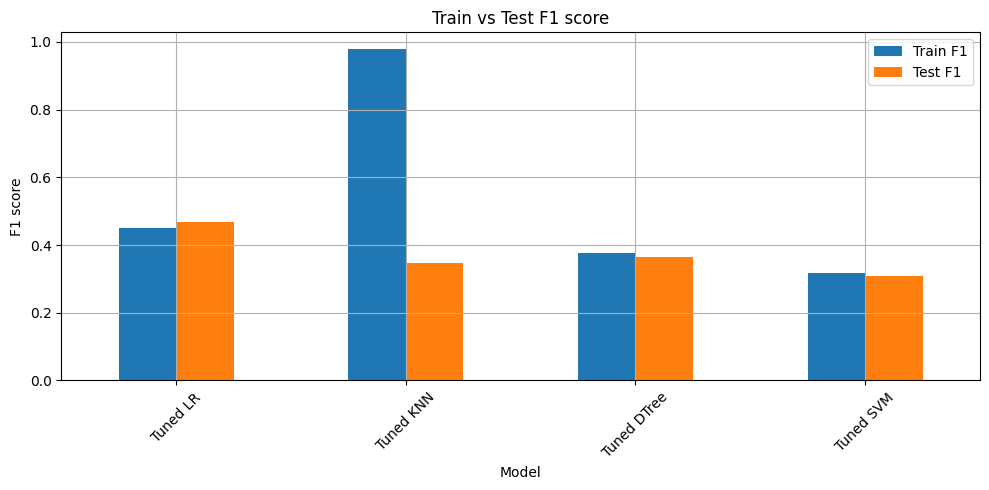

In [405]:
tuned_res.plot(
    x = "Model",
    y = ["Train F1", "Test F1"],
    kind = 'bar',
    figsize = (10, 5)
)
plt.ylabel('F1 score')
plt.title('Train vs Test F1 score')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.grid(True)
plt.show()

<font color = "MidnightBlue"> In case of choosing F1 score as metric, we can see that the tuned Knn model turned out to be overfitted. All other models show pretty good bias/variance balance. The best F1 score shows tuned LR (taking into account bias/overfit problem)

Baseline score is
F1 score: 0.11014176663031625

So all our models performed better than the baseline F1

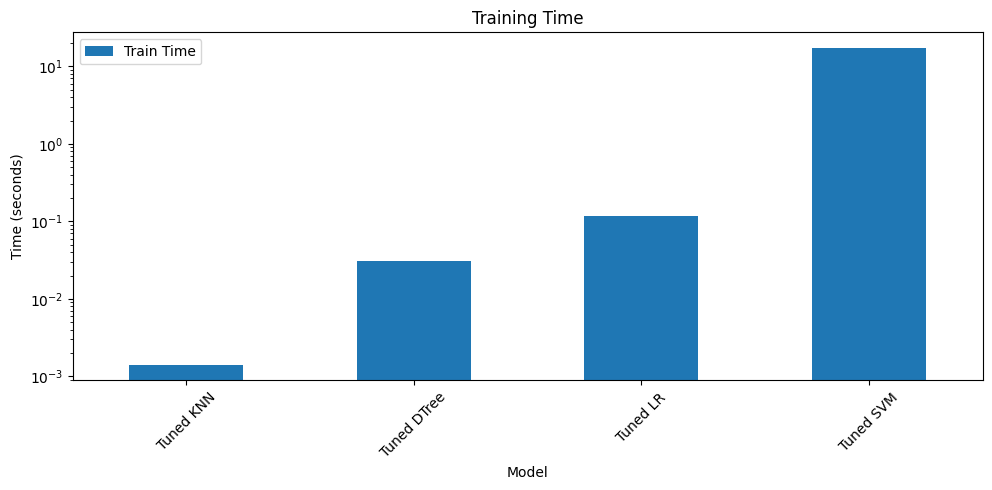

In [406]:
tuned_res.sort_values("Train Time").plot(
    x="Model",
    y="Train Time",
    kind="bar",
    figsize=(10, 5)
)

plt.ylabel("Time (seconds)")
plt.title("Training Time")
plt.xticks(rotation=45)
plt.tight_layout()
plt.yscale("log")
plt.show()



In [407]:
tuned_res

,Model,Train Time,Train F1,Test F1
0,Tuned LR,0.116869,0.451676,0.467786
1,Tuned KNN,0.001418,0.979267,0.346591
2,Tuned DTree,0.030804,0.375415,0.365217
3,Tuned SVM,17.173826,0.315917,0.307313


<font color="MidnightBlue">SVM has the longest training time among the best-performing models. The differences in training time between the models are substantial, so I used a logarithmic scale to display all the bars clearly on the same chart. </font>

### Findings

<font color="MidnightBlue">
Based on both analyses: default parameters comparison and tuned models, logistic regression showed the best results on having a good balance between bias and variance and not taking a long time. Additionally, we have to take into account that Logistic Regression is suitable not only for predictive modeling but also for interpretability. Below are the findings of the best LogReg model.

</font>

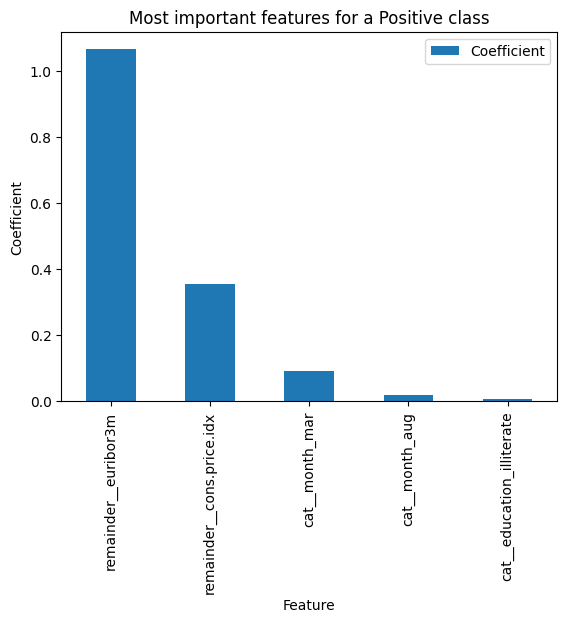

In [408]:
feature_names = preprocessor.get_feature_names_out()
best_lr = lr_grid.best_estimator_

coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': best_lr.coef_[0]
})

coef_df = coef_df.sort_values('Coefficient', ascending=False)

coef_df.head(5).plot(
    kind="bar",
    x="Feature",
    y="Coefficient"
)
plt.title("Most important features for a Positive class")
plt.xlabel("Feature")
plt.ylabel("Coefficient")
plt.show()





<font color="MidnightBlue">The strongest feature associated with the positive outcome is the 3-month Euribor interest rate. The box plot shows that customers were subscribing more during the times when the rate was lower. The median rate for the positive outcomes is less than 1.5. And the median rate for the customers who refused was almost 5. </font>

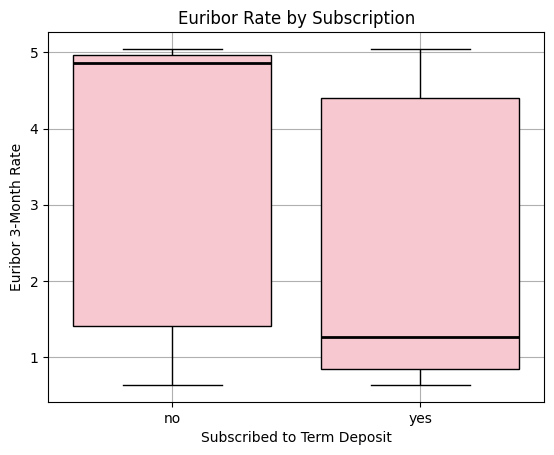

In [409]:
sns.boxplot(
    data=df,
    x="y",
    y="euribor3m",
    color="pink",
    capprops=dict(color="black"),
    boxprops=dict(edgecolor="black"),
    whiskerprops=dict(color="black"),
    medianprops=dict(color="black", linewidth=2)
)
plt.xlabel("Subscribed to Term Deposit")
plt.ylabel("Euribor 3-Month Rate")
plt.title("Euribor Rate by Subscription")
plt.grid(True)
plt.show()


<font color="MidnightBlue">
The next strong feature is the consumer price index, the higher index is associated with the negative campaign outcome.

Interestingly, March and August campaigns turned out to be in the list of the 5 most impactful features. </font>

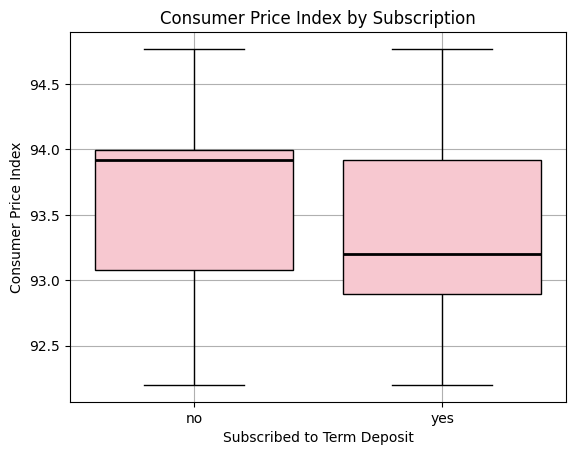

In [410]:
sns.boxplot(
    data=df,
    x="y",
    y="cons.price.idx",
    color="pink",
    capprops=dict(color="black"),
    boxprops=dict(edgecolor="black"),
    whiskerprops=dict(color="black"),
    medianprops=dict(color="black", linewidth=2)
)
plt.xlabel("Subscribed to Term Deposit")
plt.ylabel("Consumer Price Index")
plt.title("Consumer Price Index by Subscription")
plt.grid(True)
plt.show()

<font color = "MidnightBlue" >

For the negative class, the strongest association is the Employment Variation Rate. The median rate was above 1 for customers who did not subscribe to a term deposit.
</font>

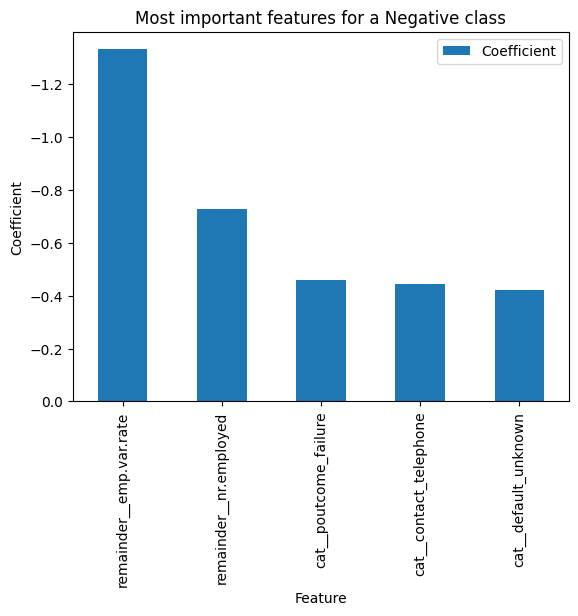

In [411]:
coef_df.tail(5).sort_values("Coefficient", ascending=True).plot(
    kind="bar",
    x="Feature",
    y="Coefficient"
)
plt.title("Most important features for a Negative class")
plt.xlabel("Feature")
plt.ylabel("Coefficient")
plt.gca().invert_yaxis()
plt.show()

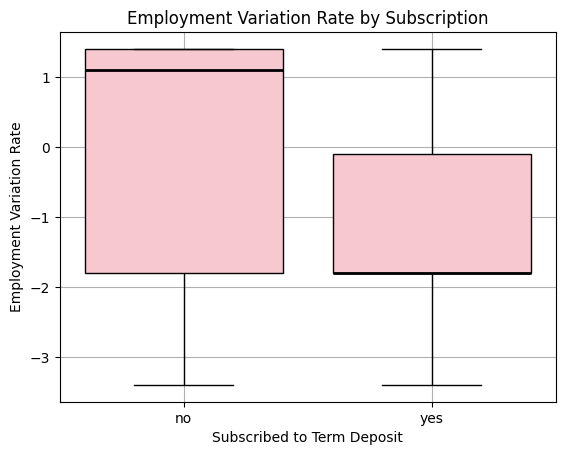

In [412]:
sns.boxplot(
    data=df,
    x="y",
    y="emp.var.rate",
    color="pink",
    capprops=dict(color="black"),
    boxprops=dict(edgecolor="black"),
    whiskerprops=dict(color="black"),
    medianprops=dict(color="black", linewidth=2)
)
plt.xlabel("Subscribed to Term Deposit")
plt.ylabel("Employment Variation Rate")
plt.title("Employment Variation Rate by Subscription")
plt.grid(True)
plt.show()

<font color="MidnightBlue">The second most important feature for the negative class is the number of employees per quarter. Higher employment levels are associated with a lower probability of subscribing to a term deposit.

It is important to note that failure in the previous marketing campaign is also a strong indicator that a customer is likely to reject the subscription. Additionally, campaigns conducted by telephone are associated with the negative class. </font>

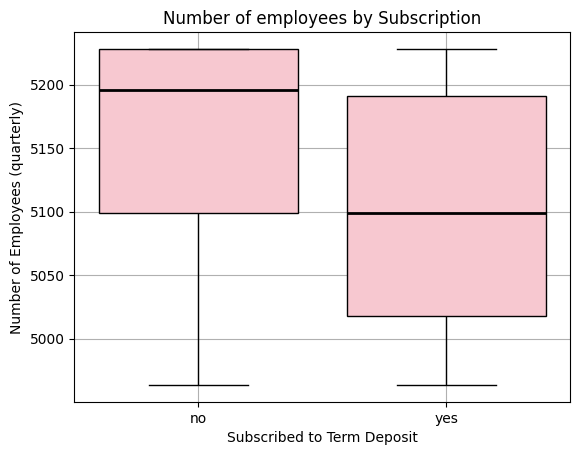

In [413]:
sns.boxplot(
    data=df,
    x="y",
    y="nr.employed",
    color="pink",
    capprops=dict(color="black"),
    boxprops=dict(edgecolor="black"),
    whiskerprops=dict(color="black"),
    medianprops=dict(color="black", linewidth=2)
)
plt.xlabel("Subscribed to Term Deposit")
plt.ylabel("Number of Employees (quarterly)")
plt.title("Number of employees by Subscription")
plt.grid(True)
plt.show()